In [1]:
import networkx as nx
import numpy as np
import random
rng = np.random.default_rng(42)
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm import tqdm

In [2]:

N = 1000 # must be divisible by communitites
communities = 10
sizes = [N // communities] * communities
p_in, p_out = 0.06, 0.002  # denser within communities

In [3]:
# 1) Base SBM (undirected template)
probs = np.full((communities, communities), p_out)
np.fill_diagonal(probs, p_in)
G_base = nx.stochastic_block_model(sizes, probs, seed=42, directed=False)

In [4]:
sizes

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100]

In [5]:
# 2) Make it directed and initialize trust weights
G = nx.DiGraph()
G.add_nodes_from(G_base.nodes(data=True))
alpha0, beta0 = 2.0, 5.0  # Beta prior skewed low
for u, v in G_base.edges():
    if rng.random() < 0.7:
        G.add_edge(u, v, w=float(rng.beta(alpha0, beta0)))
    if rng.random() < 0.7:
        G.add_edge(v, u, w=float(rng.beta(alpha0, beta0)))


In [6]:
# Node attributes (homophily features)
for node in G.nodes():
    # community is already in 'block' field from SBM
    G.nodes[node]['interest'] = rng.integers(0, 10)   # 10 topical interests
    G.nodes[node]['seniority'] = rng.normal(0, 1)     # continuous trait


In [7]:
def homophily(u, v, lam=0.8):
    iu = G.nodes[u]['interest']; iv = G.nodes[v]['interest']
    su = G.nodes[u]['seniority']; sv = G.nodes[v]['seniority']
    d = abs(iu - iv) + 0.5 * abs(su - sv)
    return np.exp(-lam * d)

def pref_attach(v, eps=1.0, alpha=0.7):
    return (G.in_degree(v) + eps) ** alpha

def reciprocity(u, v, rho=0.5):
    return rho if G.has_edge(v, u) else 0.0

def triadic_closure(u, v, theta=1.0):
    # max 2-hop trust via any k
    best = 0.0
    for k in G.successors(u):
        if G.has_edge(k, v):
            best = max(best, G[u][k]['w'] * G[k][v]['w'])
    return theta * best

def capacity_factor(u, dstar=80, kappa=0.08):
    return 1.0 / (1.0 + np.exp(kappa * (G.out_degree(u) - dstar)))

def form_prob(u, v, a=0.4, b=0.3, c=0.2, r=0.1):
    score = (a * homophily(u, v) +
             b * pref_attach(v) +
             c * triadic_closure(u, v) +
             r * reciprocity(u, v))
    return np.tanh(score) * capacity_factor(u)  # squashing + capacity

def reinforce(w, eta_pos=0.25):  # positive interaction
    return w + eta_pos * (1.0 - w)

def penalize(w, eta_neg=0.5):    # negative interaction
    return w - eta_neg * w

def decay(w, gamma=0.01):
    return w * np.exp(-gamma)


In [8]:
T = 50
tau = 0.05     # sparsity threshold
beta_prop = 0.4  # bounded propagation factor
p_interact = 0.05

for t in tqdm(range(T)):
    # Candidate sampling: mix random, homophily, pref-attach
    candidates = []
    nodes = list(G.nodes())
    for _ in range(N // 2):
        u = int(rng.integers(0, N))
        # sample v biased by homophily + pref attach
        weights = []
        for v in nodes:
            if v == u: 
                weights.append(0.0)
            else:
                weights.append(0.6 * homophily(u, v) + 0.4 * pref_attach(v))
        v = int(rng.choice(nodes, p=np.array(weights)/np.sum(weights)))
        candidates.append((u, v))

    # Attempt formations or reinforcements
    for u, v in candidates:
        if not G.has_edge(u, v):
            p = form_prob(u, v)
            if rng.random() < min(1.0, p):
                G.add_edge(u, v, w=float(rng.beta(2, 8)))
        else:
            # Simulate an interaction outcome
            if rng.random() < p_interact:
                success = rng.random() < 0.8  # base accuracy 80%
                w = G[u][v]['w']
                w = reinforce(w) if success else penalize(w)
                G[u][v]['w'] = float(np.clip(w, 0.0, 1.0))

    # Decay + prune small weights
    for u, v, data in list(G.edges(data=True)):
        G[u][v]['w'] = float(decay(data['w']))
        if G[u][v]['w'] < tau:
            G.remove_edge(u, v)

    # Bounded trust propagation (2-hop, sparse) — batched to avoid dict mutation
    to_set = []
    to_add = []
    
    for u in nodes:
        succ_u = list(G.successors(u))  # snapshot neighbor list
        for k in succ_u:
            wk = G[u][k]['w']
            if wk < 0.2:
                continue
            succ_k = list(G.successors(k))  # snapshot neighbor list
            for v in succ_k:
                if u == v:
                    continue  # optional: skip self-loops
                wkv = G[k][v]['w']
                propagated = beta_prop * wk * wkv
                if propagated <= tau:
                    continue
    
                if G.has_edge(u, v):
                    if propagated > G[u][v]['w']:
                        to_set.append((u, v, float(propagated)))
                else:
                    if rng.random() < capacity_factor(u):
                        to_add.append((u, v, float(propagated)))
    
    # Apply updates AFTER traversal
    for u, v, w in to_set:
        if w > G[u][v]['w']:
            G[u][v]['w'] = w
    
    for u, v, w in to_add:
        if G.has_edge(u, v):
            if w > G[u][v]['w']:
                G[u][v]['w'] = w
        else:
            G.add_edge(u, v, w=w)



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:17<00:00,  1.56s/it]


In [9]:
# Example diagnostics
avg_deg = np.mean([G.out_degree(n) for n in G.nodes()])
reciprocity_ratio = nx.reciprocity(G)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Average out-degree:", round(avg_deg, 2))
print("Reciprocity:", round(reciprocity_ratio or 0.0, 3))

Nodes: 1000 Edges: 37414
Average out-degree: 37.41
Reciprocity: 0.12


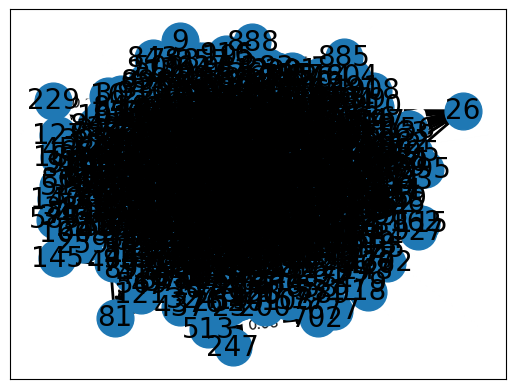

In [10]:
pos = nx.spring_layout(G, seed=23)  # positions for all nodes - seed for reproducibility
nx.draw_networkx_nodes(G, pos, node_size=700),
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2),
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
edge_labels = nx.get_edge_attributes(G, "w")
#print(edge_labels)
format_labels = {k:"%.2f"%v for k,v in edge_labels.items()}
#print(format_labels)
nx.draw_networkx_edge_labels(G, pos, format_labels)
plt.show()

In [11]:
def run_simulation(G, packets_per_node=50, rounds=10):
    packets_in = {}
    packets_out = defaultdict(int)
    for n in G.nodes:
        packets_in[n] = packets_per_node
    #print(packets_in)
    for epoch in range(rounds):
        for n in G.nodes:
            #print(n)
            neighbours = list(G.successors(n))
            #print(neighbours)
            weights = [G.edges[(n,neigh)]["w"] for neigh in neighbours]
            #print(weights)
            for inp in range(packets_in[n]):
                next_hop = random.choices(neighbours, weights=weights, k=1)[0]
                packets_out[next_hop] += 1
        #print(packets_out)
        packets_in = packets_out
        packets_out = defaultdict(int)
        #break
    return packets_in

In [62]:
final_pkt = run_simulation(G, packets_per_node=1000, rounds=5)

In [63]:
ranked = nx.pagerank(G, weight='w', alpha=1.0)

(array([ 7.,  2.,  4.,  3.,  3.,  9.,  7.,  6., 12.,  9., 15., 12., 13.,
        20., 13., 13., 21., 16., 25., 21., 29., 13., 21., 16., 21., 32.,
        22., 25., 19., 16., 16., 21., 22., 11., 25., 19., 12., 18., 22.,
        17., 21., 18., 22., 21., 21., 22., 14., 19., 13., 11., 11., 11.,
        13., 18., 12., 12., 14.,  8.,  7.,  8.,  1., 10.,  6.,  2.,  6.,
         2.,  2.,  7.,  3.,  1.,  4.,  3.,  4.,  3.,  2.,  0.,  2.,  0.,
         1.,  2.,  1.,  1.,  1.,  2.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,
         0.,  2.,  0.,  0.,  1.,  0.,  1.,  0.,  1.]),
 array([   8.,   37.,   66.,   95.,  124.,  153.,  182.,  211.,  240.,
         269.,  298.,  327.,  356.,  385.,  414.,  443.,  472.,  501.,
         530.,  559.,  588.,  617.,  646.,  675.,  704.,  733.,  762.,
         791.,  820.,  849.,  878.,  907.,  936.,  965.,  994., 1023.,
        1052., 1081., 1110., 1139., 1168., 1197., 1226., 1255., 1284.,
        1313., 1342., 1371., 1400., 1429., 1458., 1487., 1516., 1545.,
        

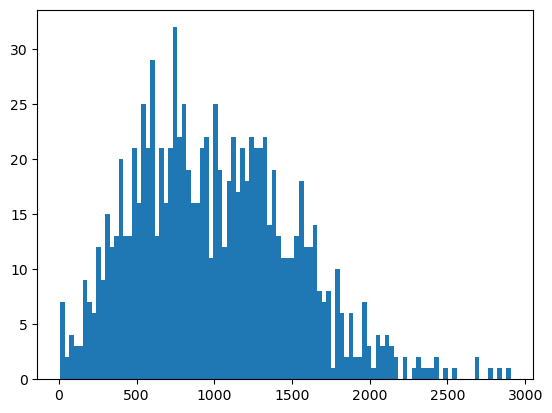

In [64]:
plt.hist(final_pkt.values(), bins=100)

In [65]:
diffs = []
for n,p in final_pkt.items():
    walk = p/sum(final_pkt.values())
    #print(n, walk, ranked[n], walk/ranked[n])
    diffs.append((walk-ranked[n], walk/ranked[n], walk, ranked[n]))

In [66]:
#list(sorted(diffs))

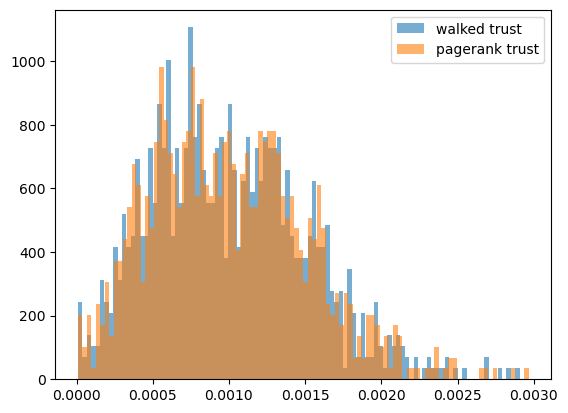

In [67]:
plt.hist([d[2] for d in diffs], bins=100, alpha=0.6, label="walked trust", density=0.5)
plt.hist([d[3] for d in diffs], bins=100, alpha=0.6, label="pagerank trust", density=0.5)
plt.legend()

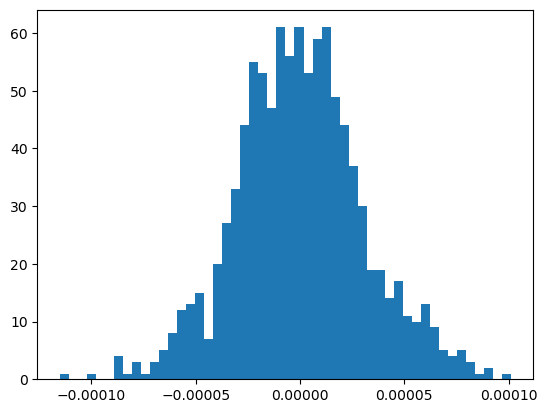

In [68]:
plt.hist([d[0] for d in diffs], bins=50, label="absolute diffs")
plt.show()

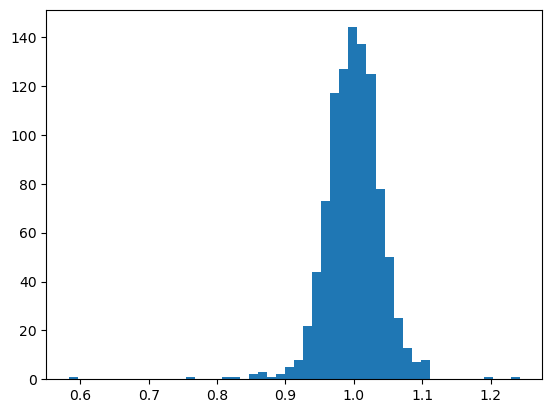

In [61]:
plt.hist([d[1] for d in diffs], bins=50, label="relative diffs")
plt.show()

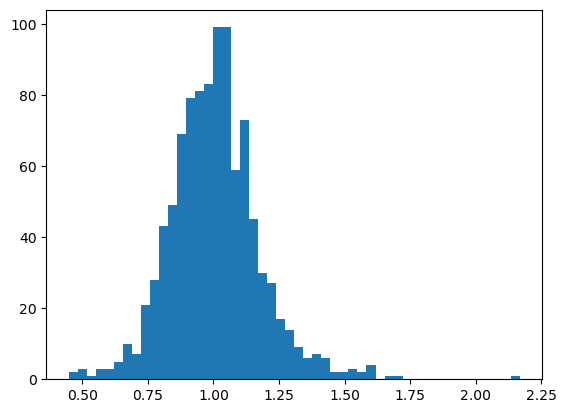

In [20]:
plt.hist([d[1] for d in diffs], bins=50, label="relative diffs")
plt.show()

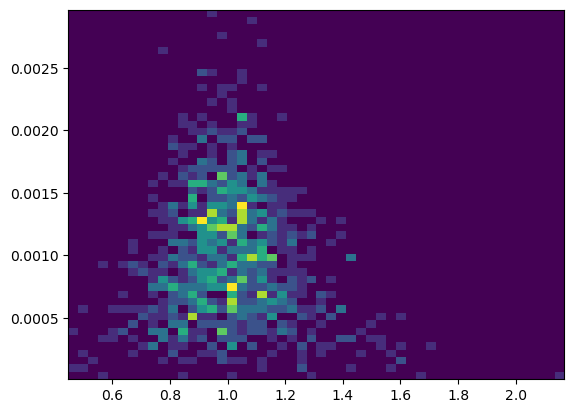

In [21]:
plt.hist2d([d[1] for d in diffs],[d[3] for d in diffs], bins=50)
plt.show()

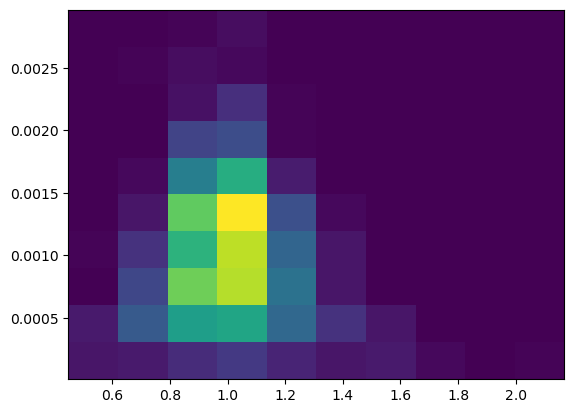

In [22]:
plt.hist2d([d[1] for d in diffs],[d[3] for d in diffs])
plt.show()

Great question, Felix. If you want a **synthetic directed trust graph** that “feels” human, you’ll want to combine (1) a base network topology that matches real social structure and (2) **behavioral rules** that govern how trust forms, propagates, strengthens, and decays.

Below is a practical blueprint you can adapt, with design principles, generative models, and example code to get you started.

***

## 1) What makes a graph “social” and “human-like”?

Target these empirical stylized facts:

*   **Heavy-tailed degree distribution** (a few hubs, many with small degree).
*   **High clustering** (friends of friends tend to connect).
*   **Small-world** (short average path lengths).
*   **Homophily** (similar agents are more likely to connect).
*   **Triadic closure** (A trusts B, B trusts C ⇒ A is more likely to consider C).
*   **Reciprocity** (trust often becomes mutual, but not always).
*   **Limited capacity** (bounded out-degree; think Dunbar-like limits per context).
*   **Aging & bursts** (trust updates happen in bursts and decay over time).
*   **Context specificity** (trust differs by topic/domain).

***

## 2) Choose a base topology

Pick a generative model as a backbone, then layer trust semantics on top:

*   **Preferential Attachment (Barabási–Albert)**: good for hubs and heavy tails.
*   **Small-World (Watts–Strogatz)**: high clustering + short paths.
*   **Stochastic Block Models (SBM)**: to encode **communities** and **homophily**.
*   **Kronecker / R-MAT**: scalable, self-similar structure.
*   **ERGMs / Latent Space models**: statistically match observed properties (heavier setup).

**Recommendation:**  
Start with **SBM + small-world rewiring per community** to get communities and clustering. Then overlay **preferential attachment** for “popular experts”.

***

## 3) Add trust as **directed, weighted** edges

*   Each directed edge $$i \to j$$ has a weight $$w_{ij} \in [0,1]$$ (trust level).
*   Initialize with a prior distribution, e.g. **Beta(α, β)** per context.
*   Enforce **capacity constraints** on out-degree (e.g., logistic cost to maintain many trust relations).

***

## 4) Core behavioral rules

You can simulate time steps where agents encounter each other and update trust.

### 4.1 Formation rules

*   **Homophily**: $$P(i \to j) \propto \exp(-\lambda \cdot d(\text{attrs}_i,\text{attrs}_j))$$
*   **Preferential attachment**: $$P(i \to j) \propto (k^{in}_j + \epsilon)^\alpha$$
*   **Triadic closure**: If $$i \to k$$ and $$k \to j$$ with high $$w_{ik}, w_{kj}$$, increase $$P(i \to j)$$.
*   **Reciprocity bias**: If $$j \to i$$ exists, boost $$P(i \to j)$$.

### 4.2 Update rules (reinforcement & decay)

*   **Positive interaction** (successful recommendation, accurate info):
    $$
    w_{ij} \leftarrow w_{ij} + \eta^+ (1 - w_{ij})
    $$
*   **Negative interaction** (breach, inaccuracy):
    $$
    w_{ij} \leftarrow w_{ij} - \eta^- w_{ij}
    $$
*   **Time decay** (no interaction over Δt):
    $$
    w_{ij} \leftarrow w_{ij} \cdot e^{-\gamma \Delta t}
    $$

### 4.3 Trust propagation (bounded)

*   For transitivity, compute limited 2-hop influence:
    $$
    \tilde{w}_{ij} = \max\left(w_{ij}, \ \beta \cdot \max_{k}(w_{ik} \cdot w_{kj})\right)
    $$
    Clip to \[0,1] and apply sparsity threshold τ to avoid dense explosions.

### 4.4 Bounded capacity & attention

*   **Cost of maintenance**: Increase friction to add edges as out-degree grows:
    $$
    P(\text{new } i\to j) \leftarrow P(\text{new } i\to j) \cdot \sigma\left(\kappa (d^* - \text{outdeg}(i))\right)
    $$
    where $$d^*$$ is a soft cap (e.g., 50–150 depending on domain).

### 4.5 Context-specific trust (multiplex)

*   Maintain separate layers per domain (e.g., **technical**, **personal**, **financial**).  
    Propagate within-layer strongly; cross-layer weakly with a small coupling factor.

### 4.6 Reputation & global signals

*   Maintain a **PageRank-like** or **eigenvector centrality** score as “reputation”.  
    Use it to bias future edge formations (but cap its effect to avoid monoculture).

### 4.7 Noise, shocks & churn

*   Introduce small random perturbations and occasional shocks (scandals, policy changes) to test robustness and realism.

***

## 5) A step-by-step synthetic generator (recipe)

**Parameters to set:**

*   $$N$$: number of agents
*   Community count and sizes
*   Homophily strength $$\lambda$$
*   Triadic closure weight $$\theta$$
*   Reciprocation weight $$\rho$$
*   Decay $$\gamma$$, learning rates $$\eta^+, \eta^-$$
*   Capacity soft cap $$d^*$$, steepness $$\kappa$$
*   Propagation factor $$\beta$$, threshold $$\tau$$

**Algorithm outline:**

1.  **Assign attributes** (community, interests, seniority).
2.  **Base structure**: Generate SBM to seed communities. Optionally, within each block, apply Watts–Strogatz rewiring for clustering.
3.  **Initialize trust**: For a subset of pairs in the base edges, set $$w_{ij} \sim \text{Beta}(α, β)$$; enforce directionality.
4.  **Simulate T steps**:
    *   Sample candidate pairs using a mixture of:
        *   Homophily-based sampling
        *   Preferential attachment to high-reputation nodes
        *   Triadic closure candidates via 2-hop neighborhoods
    *   For each candidate, compute edge formation probability combining:
        $$
        P = \text{normalize}\Big(a \cdot \text{homophily} + b \cdot \text{prefAttach} + c \cdot \text{triadic} + r \cdot \text{reciprocity}\Big)
        $$
        Apply capacity factor and stochastic accept/reject.
    *   Draw interactions for existing edges; update $$w_{ij}$$ via reinforcement/penalty.
    *   Apply decay and bounded trust propagation with threshold.
    *   Periodically recompute reputation (e.g., every 10 steps).
5.  **Prune & normalize**: Drop edges with $$w_{ij} < \tau$$. Optionally renormalize out-neighborhood weights.

***

## 6) Example: Minimal Python prototype (NetworkX)

```python
import networkx as nx
import numpy as np
rng = np.random.default_rng(42)

N = 1000
communities = 8
sizes = [N // communities] * communities
p_in, p_out = 0.06, 0.002  # denser within communities

# 1) Base SBM (undirected template)
probs = np.full((communities, communities), p_out)
np.fill_diagonal(probs, p_in)
G_base = nx.stochastic_block_model(sizes, probs, seed=42, directed=False)

# 2) Make it directed and initialize trust weights
G = nx.DiGraph()
G.add_nodes_from(G_base.nodes(data=True))
alpha0, beta0 = 2.0, 5.0  # Beta prior skewed low
for u, v in G_base.edges():
    if rng.random() < 0.7:
        G.add_edge(u, v, w=float(rng.beta(alpha0, beta0)))
    if rng.random() < 0.7:
        G.add_edge(v, u, w=float(rng.beta(alpha0, beta0)))

# Node attributes (homophily features)
for node in G.nodes():
    # community is already in 'block' field from SBM
    G.nodes[node]['interest'] = rng.integers(0, 10)   # 10 topical interests
    G.nodes[node]['seniority'] = rng.normal(0, 1)     # continuous trait

def homophily(u, v, lam=0.8):
    iu = G.nodes[u]['interest']; iv = G.nodes[v]['interest']
    su = G.nodes[u]['seniority']; sv = G.nodes[v]['seniority']
    d = abs(iu - iv) + 0.5 * abs(su - sv)
    return np.exp(-lam * d)

def pref_attach(v, eps=1.0, alpha=0.7):
    return (G.in_degree(v) + eps) ** alpha

def reciprocity(u, v, rho=0.5):
    return rho if G.has_edge(v, u) else 0.0

def triadic_closure(u, v, theta=1.0):
    # max 2-hop trust via any k
    best = 0.0
    for k in G.successors(u):
        if G.has_edge(k, v):
            best = max(best, G[u][k]['w'] * G[k][v]['w'])
    return theta * best

def capacity_factor(u, dstar=80, kappa=0.08):
    return 1.0 / (1.0 + np.exp(kappa * (G.out_degree(u) - dstar)))

def form_prob(u, v, a=0.4, b=0.3, c=0.2, r=0.1):
    score = (a * homophily(u, v) +
             b * pref_attach(v) +
             c * triadic_closure(u, v) +
             r * reciprocity(u, v))
    return np.tanh(score) * capacity_factor(u)  # squashing + capacity

def reinforce(w, eta_pos=0.25):  # positive interaction
    return w + eta_pos * (1.0 - w)

def penalize(w, eta_neg=0.5):    # negative interaction
    return w - eta_neg * w

def decay(w, gamma=0.01):
    return w * np.exp(-gamma)

T = 50
tau = 0.05     # sparsity threshold
beta_prop = 0.4  # bounded propagation factor
p_interact = 0.05

for t in range(T):
    # Candidate sampling: mix random, homophily, pref-attach
    candidates = []
    nodes = list(G.nodes())
    for _ in range(N // 2):
        u = int(rng.integers(0, N))
        # sample v biased by homophily + pref attach
        weights = []
        for v in nodes:
            if v == u: 
                weights.append(0.0)
            else:
                weights.append(0.6 * homophily(u, v) + 0.4 * pref_attach(v))
        v = int(rng.choice(nodes, p=np.array(weights)/np.sum(weights)))
        candidates.append((u, v))

    # Attempt formations or reinforcements
    for u, v in candidates:
        if not G.has_edge(u, v):
            p = form_prob(u, v)
            if rng.random() < min(1.0, p):
                G.add_edge(u, v, w=float(rng.beta(2, 8)))
        else:
            # Simulate an interaction outcome
            if rng.random() < p_interact:
                success = rng.random() < 0.8  # base accuracy 80%
                w = G[u][v]['w']
                w = reinforce(w) if success else penalize(w)
                G[u][v]['w'] = float(np.clip(w, 0.0, 1.0))

    # Decay + prune small weights
    for u, v, data in list(G.edges(data=True)):
        G[u][v]['w'] = float(decay(data['w']))
        if G[u][v]['w'] < tau:
            G.remove_edge(u, v)

    # Bounded trust propagation (2-hop, sparse)
    for u in nodes:
        for k in G.successors(u):
            wk = G[u][k]['w']
            if wk < 0.2: 
                continue
            for v in G.successors(k):
                wkv = G[k][v]['w']
                propagated = beta_prop * wk * wkv
                if propagated > tau:
                    if G.has_edge(u, v):
                        G[u][v]['w'] = float(max(G[u][v]['w'], propagated))
                    else:
                        # respect capacity
                        if rng.random() < capacity_factor(u):
                            G.add_edge(u, v, w=float(propagated))

# Example diagnostics
avg_deg = np.mean([G.out_degree(n) for n in G.nodes()])
reciprocity_ratio = nx.reciprocity(G)
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Average out-degree:", round(avg_deg, 2))
print("Reciprocity:", round(reciprocity_ratio or 0.0, 3))
```

**Notes**

*   This is a **toy**—tune parameters for your domain (enterprise, research collaboration, consumer social).
*   To add **multiple contexts**, maintain parallel graphs/layers or a vector $$\mathbf{w}_{ij}$$ per edge (one weight per domain).

***

## 7) Calibration & validation

Measure whether your graph behaves like human networks:

*   **Degree distribution**: fits power-law or log-normal? (use KS tests/BIC).
*   **Clustering coefficient**: global & average local.
*   **Assortativity**: by degree and by attributes (homophily).
*   **Path length / diameter**: small-world property.
*   **Reciprocity**: fraction of mutual links.
*   **Community structure**: modularity (Louvain/Leiden).
*   **Temporal realism**: bursts, decay curves, stability of “core” ties.
*   **Robustness**: sensitivity to shocks; resilience to removal of hubs.

If you have any real data (even partial), **fit** homophily and closure weights to match these metrics and then **simulate**.

***

## 8) Practical rules of thumb

*   Keep **propagation bounded** (2-hop only + threshold) to avoid unrealistic densification.
*   Enforce **capacity constraints** to prevent everyone trusting everyone.
*   Use **asymmetric updates** (penalties stronger than rewards) to reflect loss aversion.
*   Include **noise** and occasional **reversals** to avoid frozen networks.
*   If you expect distrust, model **signed edges** and apply **structural balance** rules (friend-of-my-enemy logic).

***

## 9) Extensions

*   **Agent heterogeneity**: Different temperaments (trusting vs skeptical), different learning rates.
*   **Reputation systems**: Combine local trust with global rep scores for routing decisions.
*   **Context coupling**: Technical trust spills over into professional trust slightly; personal trust less so.
*   **Fairness & bias checks**: Watch for homophily-induced segregation; introduce exploration to diversify.

***

If you share your **target size (N)**, **domain** (e.g., research collaboration, consumer social, enterprise), and whether you need **multiplex** (per-topic) trust, I can tailor the parameters and provide a ready-to-run, well-documented generator—including plots and summary metrics.
